In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("happiness inflation unemployment.csv")

In [15]:
df.head()



,country,year,happiness_score,inflation_rate,unemployment_rate
0,Afghanistan,2015,3.575,-0.660,9.032
1,Afghanistan,2016,3.360,4.380,10.116
2,Afghanistan,2017,3.794,4.976,11.184
3,Afghanistan,2018,3.632,0.630,11.192
4,Afghanistan,2019,3.203,2.302,11.187


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            1218 non-null   object 
 1   year               1218 non-null   int64  
 2   happiness_score    1218 non-null   float64
 3   inflation_rate     1186 non-null   float64
 4   unemployment_rate  1218 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 47.7+ KB


In [17]:
df.describe()

,year,happiness_score,inflation_rate,unemployment_rate
count,1218.000000,1218.000000,1186.000000,1218.000000
mean,2018.891626,5.494702,7.432279,7.234999
std,2.553888,1.139458,25.303469,5.511619
min,2015.000000,1.859000,-3.752996,0.100000
25%,2017.000000,4.609250,1.429068,3.647000
50%,2019.000000,5.531000,3.505115,5.401500
75%,2021.000000,6.333250,6.881990,9.295250
max,2023.000000,7.842000,557.210000,34.153000


In [18]:
df.isnull().sum()

country               0
year                  0
happiness_score       0
inflation_rate       32
unemployment_rate     0
dtype: int64

In [19]:
# Averages by country

In [20]:
country_avg = (
    df.groupby("country")
      [["happiness_score", "inflation_rate", "unemployment_rate"]]
      .mean()
)

print(country_avg)

             happiness_score  inflation_rate  unemployment_rate
country                                                        
Afghanistan         2.990778        4.091625          11.615000
Albania             4.893222        2.731355          12.729333
Algeria             5.409000        5.497095          12.176111
Angola              3.872250       22.752683          16.565750
Argentina           6.243556       52.301261           8.468444
...                      ...             ...                ...
Uruguay             6.443889        8.054417           8.484889
Uzbekistan          6.082778       11.941279           5.112778
Vietnam             5.309444        2.738625           1.790333
Zambia              4.277333       12.393353           5.486333
Zimbabwe            3.630667      125.410684           7.710889

[146 rows x 3 columns]


In [21]:
# Averages by year

In [22]:
year_avg = (
    df.groupby("year")
      [["happiness_score", "inflation_rate", "unemployment_rate"]]
      .mean()
)

print(year_avg)

      happiness_score  inflation_rate  unemployment_rate
year                                                    
2015         5.432908        3.688707           7.745915
2016         5.433777        7.195220           7.548201
2017         5.408921        6.082197           7.282371
2018         5.438450        5.079074           6.992386
2019         5.474892        5.858682           6.897842
2020         5.523672        8.640688           7.946555
2021         5.575687        6.988909           7.708612
2022         5.597328       13.000463           6.651203
2023         5.593558       11.439442           6.171692


In [23]:
# Average happiness by year

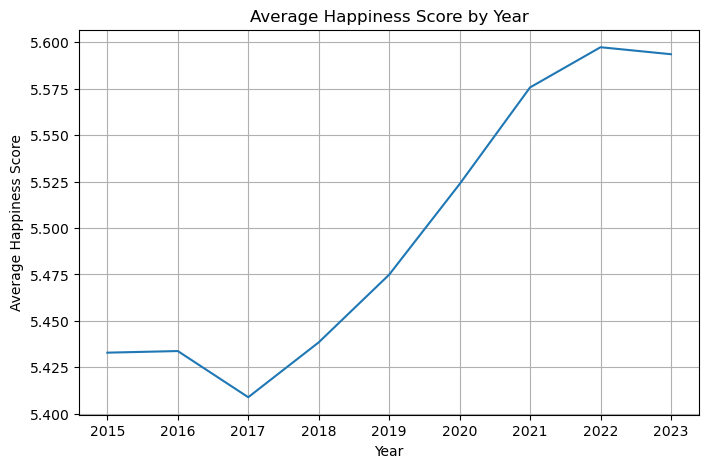

In [24]:
yearly_happiness = df.groupby("year")["happiness_score"].mean()

plt.figure(figsize=(8,5))
plt.plot(yearly_happiness.index, yearly_happiness.values)
plt.title("Average Happiness Score by Year")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")
plt.grid(True)
plt.show()

In [25]:
# Average inflation rate by year

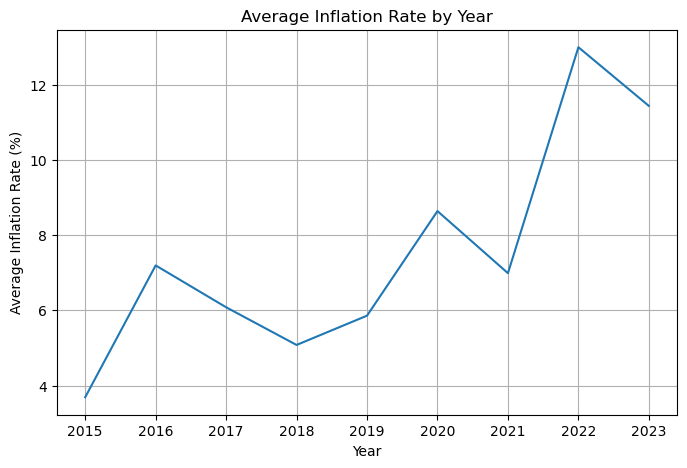

In [26]:
yearly_inflation = df.groupby("year")["inflation_rate"].mean()

plt.figure(figsize=(8,5))
plt.plot(yearly_inflation.index, yearly_inflation.values)
plt.title("Average Inflation Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average Inflation Rate (%)")
plt.grid(True)
plt.show()

In [27]:
# Average unemployment rate by year

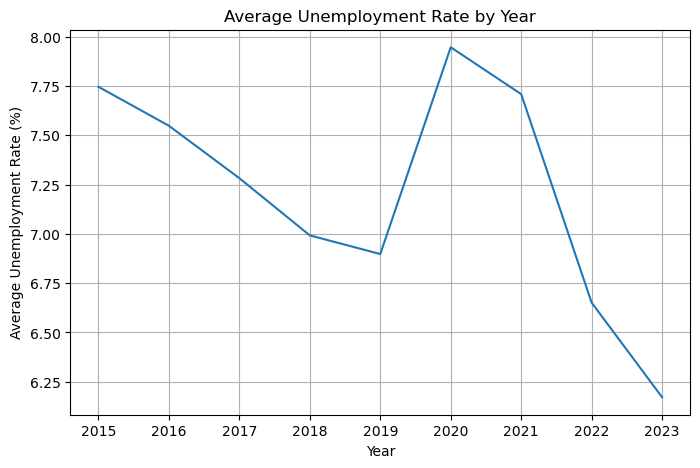

In [28]:
yearly_unempoloyment = df.groupby("year")["unemployment_rate"].mean()

plt.figure(figsize=(8,5))
plt.plot(yearly_unempoloyment.index, yearly_unempoloyment.values)
plt.title("Average Unemployment Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid(True)
plt.show()

In [29]:
# Inflation vs Happiness scatter plot

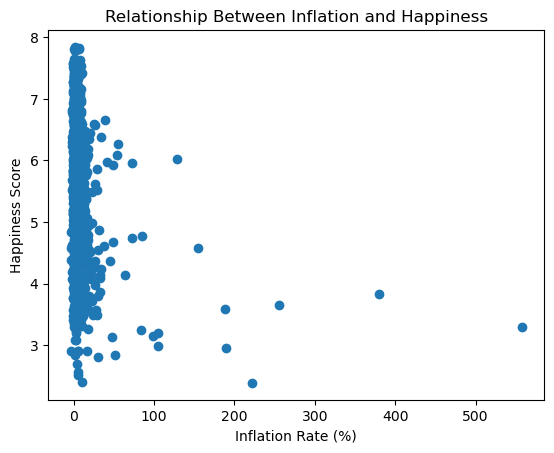

In [30]:

plt.scatter(df["inflation_rate"], df["happiness_score"])

plt.xlabel("Inflation Rate (%)")
plt.ylabel("Happiness Score")
plt.title("Relationship Between Inflation and Happiness")
plt.show()

In [31]:
# Unemployment vs Happiness scatter plot

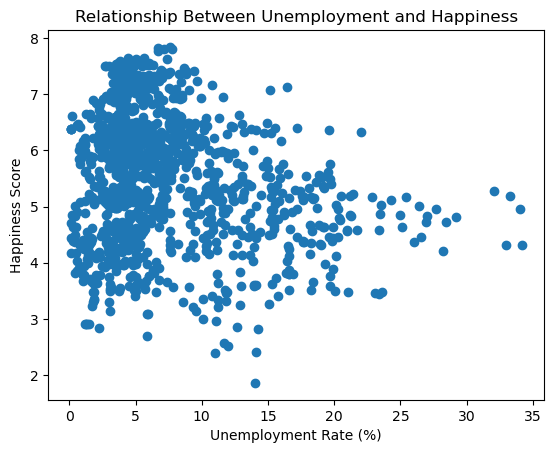

In [32]:
plt.scatter(df["unemployment_rate"], df["happiness_score"])

plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Happiness Score")
plt.title("Relationship Between Unemployment and Happiness")
plt.show()

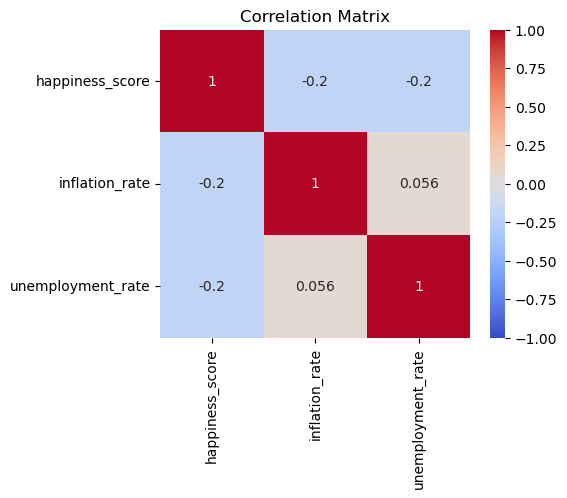

In [33]:

correlation = df[["happiness_score",
           "inflation_rate",
           "unemployment_rate"]].corr()
plt.figure(figsize=(5,4))
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlation Matrix")
plt.show()